# Train a CNN on a small dataset

CPU companion; no accelerator is required. TPU execution not validated.

- Generate images with an explicit label rule
- Derive the convolution output shape
- Pool spatial responses and retain class scores
- Read a confusion matrix rather than a success label

Can a small model tell horizontal bars from vertical bars in noisy images? We’ll create the images locally and train a convolutional classifier on CPU. You’ll then test images from a different random seed and read a confusion matrix. The task is small enough to inspect without downloading a dataset.

## The idea

A convolution combines a local input patch with weights reused across spatial positions. Layout, stride and padding decide which pixels contribute to each output. Trace one position first; the full feature map repeats that same rule.

## Trace one convolution output

In a separate shape example, a three-by-three kernel sliding over a five-by-five image with stride one and no padding has three valid positions along each axis. It produces a three-by-three output per filter.

For one output location, multiply the selected patch by the kernel and sum over spatial and input-channel axes, then add the filter bias. Moving to another location changes the patch while reusing the filter. A new padding or stride convention changes the indexing contract.

The confusion matrix answers a later question about classification errors. Pick one off-diagonal cell, identify its true/predicted labels, and inspect an image from that cell. Correct synthetic-shape classification does not establish recognition of natural photographs.

### Pixels behind one convolution output

**Predict:** What stays shared when the kernel moves?

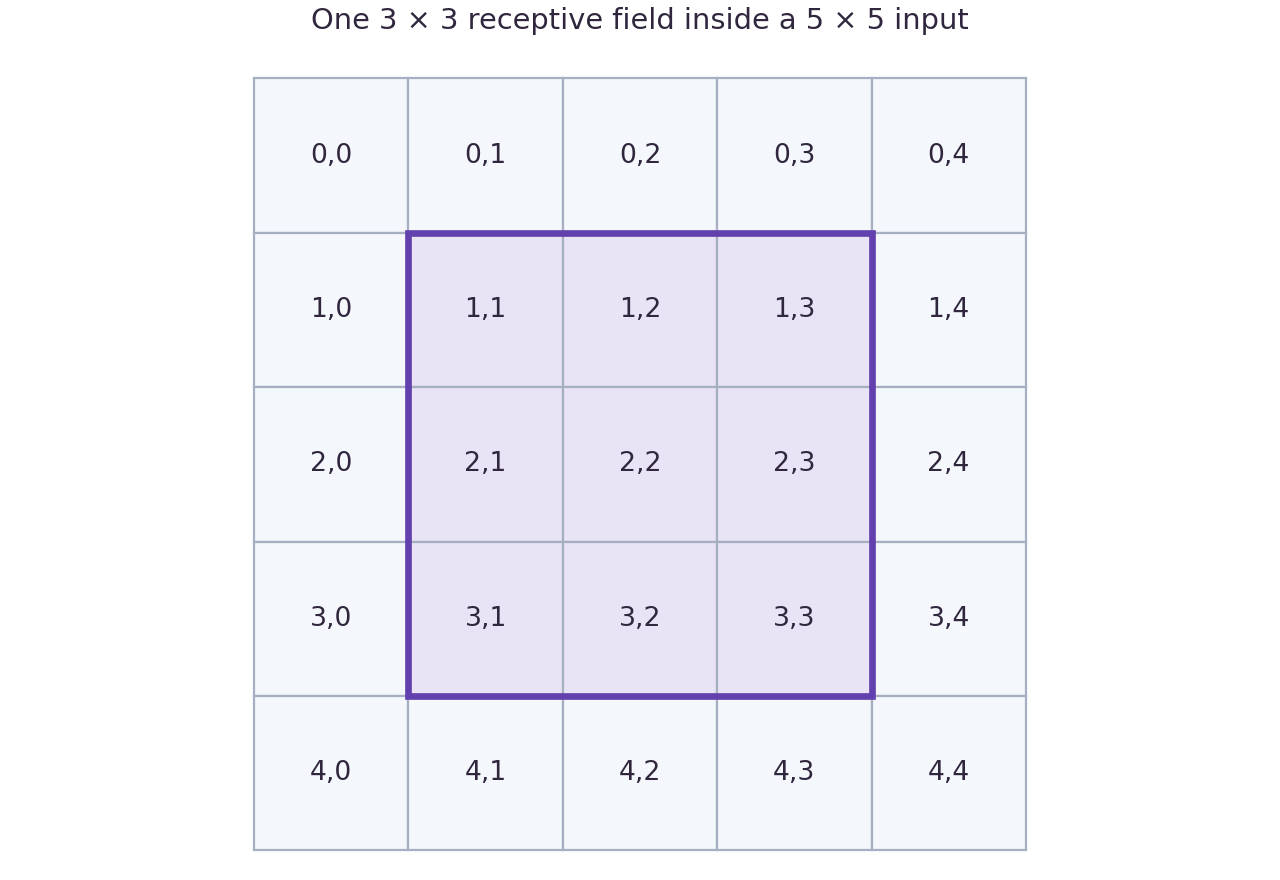

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

The purple square selects one three-by-three patch within a five-by-five input. Each selected cell contributes to one output under the declared convolution. Moving the patch reuses weights. This separate shape example has three valid positions per axis at stride one without padding; it does not display learned weights.

### Pause and reason

What stays shared when the kernel moves?

<details><summary>Compare your reasoning</summary>

The filter weights and bias. The input patch changes. This is different from learning unrelated weights at every spatial location.

</details>

## Generate images with an explicit label rule

Our images have height eight, width eight, and one channel. Class zero contains a horizontal bright bar; class one contains a vertical bright bar. The bar position varies among interior rows or columns, and independent Gaussian noise perturbs every pixel. Alternate labels so both splits are balanced. Generate training and held-out sets from different seeds; identical seeds would reproduce images and create leakage. Every observation follows a known rule, so inspect a few images and labels before training. This synthetic distribution contains no occlusion, perspective, or multiple objects and should never be described as realistic vision evaluation.

## Derive the convolution output shape

NNX Conv accepts channels-last arrays: batch, height, width, channels. A $3\times3$ filter with stride one and VALID padding slides only where the whole patch fits. An $8\times8$ image therefore yields $6\times6$ spatial outputs. Four output channels mean four independently learned filters; the kernel shape is $(3, 3, 1, 4)$, followed by four biases. Each output is a patch dot product plus a bias. Deep-learning convolution uses cross-correlation here: do not reverse the filter in the independent NumPy reference. We check one interior output explicitly before fitting, which catches axis or padding misunderstandings.

```text
(B,8,8,1) → Conv3×3/VALID → (B,6,6,4) → ReLU → spatial mean → (B,4) → Linear → (B,2)
```

## Pool spatial responses and retain class scores

ReLU replaces negative filter responses with zero. Averaging axes one and two summarizes how strongly each learned pattern appears anywhere in the remaining image. Pooling discards exact position, which suits orientation classification but would hurt a task asking for bar location. The classifier head emits two logits per image. softmax_cross_entropy_with_integer_labels consumes those scores and integer labels directly; do not apply softmax beforehand. A stable independent NumPy reference subtracts the largest score before computing log-sum-exp. The objective is averaged over observations, not over classes.

## Read a confusion matrix rather than a success label

Use rows for true classes and columns for predicted classes. The diagonal counts correct classifications; off-diagonal cells identify orientation-specific mistakes. A balanced 24-image held-out set contains $12$ examples per class, so a model always predicting horizontal has accuracy $0.5$. After training, print both held-out mean loss and accuracy, along with all four confusion counts. Check that the matrix sums to $24$ and that its trace divided by $24$ equals accuracy. This independent accounting prevents a reduction-axis error from looking like good performance. Keep the split and hyperparameters fixed; a new data distribution is a new experiment, not another chance to select the reported test result.

## 1. Generate two disjoint synthetic splits

Create main.py. Print a training image as an $8\times8$ array if you want to inspect the task before fitting.

In [1]:
from flax import nnx
import jax
import jax.numpy as jnp
import numpy as np
import optax
def bars(seed,n,noise=.08):
    rng=np.random.default_rng(seed)
    images=np.zeros((n,8,8,1),np.float32)
    labels=np.arange(n,dtype=np.int32)%2
    for i,label in enumerate(labels):
        position=int(rng.integers(2,6))
        if label==0:images[i,position,:,0]=1.
        else:images[i,:,position,0]=1.
    images+=rng.normal(0,noise,images.shape).astype(np.float32)
    return jnp.array(images),jnp.array(labels)
train_x,train_y=bars(20,48)
test_x,test_y=bars(21,24)
assert train_x.shape==(48,8,8,1) and test_x.shape==(24,8,8,1)
assert not np.array_equal(np.asarray(train_x[:24]),np.asarray(test_x))

Two seeds produce separate examples. Both labels are balanced by construction; noise can make orientation harder as its scale grows.

## 2. Build and independently inspect the convolution

Append the small CNN and the patch dot-product check before defining an optimizer.

In [2]:
class BarCNN(nnx.Module):
    def __init__(self):
        rngs=nnx.Rngs(0)
        self.conv=nnx.Conv(1,4,(3,3),padding='VALID',rngs=rngs)
        self.head=nnx.Linear(4,2,rngs=rngs)
    def __call__(self,x):
        features=jnp.mean(nnx.relu(self.conv(x)),axis=(1,2))
        return self.head(features)
model=BarCNN()
raw=model.conv(train_x[:1])
assert raw.shape==(1,6,6,4)
patch=np.asarray(train_x[0,:3,:3,:])
kernel=np.asarray(model.conv.kernel[...])
expected=np.sum(patch*kernel[:,:,:,0])+np.asarray(model.conv.bias[...])[0]
np.testing.assert_allclose(raw[0,0,0,0],expected,rtol=1e-5,atol=1e-6)
def loss(m,x,y):return jnp.mean(optax.softmax_cross_entropy_with_integer_labels(m(x),y))
optimizer=nnx.Optimizer(model,optax.adam(.03),wrt=nnx.Param)
@nnx.jit
def train_step(m,o,x,y):
    value,grads=nnx.value_and_grad(loss)(m,x,y)
    o.update(m,grads)
    return value

The first output at $(0,0)$ consumes exactly the top-left $3\times3$ patch. The NumPy result validates filter orientation and layout.

## 3. Fit, then measure the held-out split once

Append $80$ full-batch updates, stable NumPy loss, and confusion accounting. Every update uses only train_x/train_y.

In [3]:
initial=float(loss(model,train_x,train_y))
for _ in range(80):train_step(model,optimizer,train_x,train_y)
scores=np.asarray(model(test_x));labels=np.asarray(test_y)
predictions=scores.argmax(axis=-1)
shifted=scores-scores.max(axis=-1,keepdims=True)
reference_loss=np.mean(np.log(np.exp(shifted).sum(axis=-1))-shifted[np.arange(len(labels)),labels])
np.testing.assert_allclose(loss(model,test_x,test_y),reference_loss,rtol=1e-5,atol=1e-6)
confusion=np.zeros((2,2),dtype=int)
np.add.at(confusion,(labels,predictions),1)
accuracy=np.mean(predictions==labels)
assert confusion.sum()==24 and np.isclose(np.trace(confusion)/24,accuracy)
assert accuracy>=.9 and float(loss(model,train_x,train_y))<initial*.3
print('Held-out loss:',reference_loss,'accuracy:',accuracy,'confusion:\n',confusion)

Held-out loss: 0.015700625 accuracy: 1.0 confusion:
 [[12  0]
 [ 0 12]]


The output is a measured CPU result for synthetic bars. No MNIST, TPU, or throughput claim is implied.

## Run the example

In [4]:
from flax import nnx
import jax
import jax.numpy as jnp
import numpy as np
import optax
def bars(seed,n,noise=.08):
    rng=np.random.default_rng(seed)
    images=np.zeros((n,8,8,1),np.float32)
    labels=np.arange(n,dtype=np.int32)%2
    for i,label in enumerate(labels):
        position=int(rng.integers(2,6))
        if label==0:images[i,position,:,0]=1.
        else:images[i,:,position,0]=1.
    images+=rng.normal(0,noise,images.shape).astype(np.float32)
    return jnp.array(images),jnp.array(labels)
train_x,train_y=bars(20,48)
test_x,test_y=bars(21,24)
assert train_x.shape==(48,8,8,1) and test_x.shape==(24,8,8,1)
assert not np.array_equal(np.asarray(train_x[:24]),np.asarray(test_x))

class BarCNN(nnx.Module):
    def __init__(self):
        rngs=nnx.Rngs(0)
        self.conv=nnx.Conv(1,4,(3,3),padding='VALID',rngs=rngs)
        self.head=nnx.Linear(4,2,rngs=rngs)
    def __call__(self,x):
        features=jnp.mean(nnx.relu(self.conv(x)),axis=(1,2))
        return self.head(features)
model=BarCNN()
raw=model.conv(train_x[:1])
assert raw.shape==(1,6,6,4)
patch=np.asarray(train_x[0,:3,:3,:])
kernel=np.asarray(model.conv.kernel[...])
expected=np.sum(patch*kernel[:,:,:,0])+np.asarray(model.conv.bias[...])[0]
np.testing.assert_allclose(raw[0,0,0,0],expected,rtol=1e-5,atol=1e-6)
def loss(m,x,y):return jnp.mean(optax.softmax_cross_entropy_with_integer_labels(m(x),y))
optimizer=nnx.Optimizer(model,optax.adam(.03),wrt=nnx.Param)
@nnx.jit
def train_step(m,o,x,y):
    value,grads=nnx.value_and_grad(loss)(m,x,y)
    o.update(m,grads)
    return value

initial=float(loss(model,train_x,train_y))
for _ in range(80):train_step(model,optimizer,train_x,train_y)
scores=np.asarray(model(test_x));labels=np.asarray(test_y)
predictions=scores.argmax(axis=-1)
shifted=scores-scores.max(axis=-1,keepdims=True)
reference_loss=np.mean(np.log(np.exp(shifted).sum(axis=-1))-shifted[np.arange(len(labels)),labels])
np.testing.assert_allclose(loss(model,test_x,test_y),reference_loss,rtol=1e-5,atol=1e-6)
confusion=np.zeros((2,2),dtype=int)
np.add.at(confusion,(labels,predictions),1)
accuracy=np.mean(predictions==labels)
assert confusion.sum()==24 and np.isclose(np.trace(confusion)/24,accuracy)
assert accuracy>=.9 and float(loss(model,train_x,train_y))<initial*.3
print('Held-out loss:',reference_loss,'accuracy:',accuracy,'confusion:\n',confusion)

Held-out loss: 0.015700625 accuracy: 1.0 confusion:
 [[12  0]
 [ 0 12]]


Expected: Held-out accuracy is at least $0.9$ for the fixed fixture; confusion counts total $24$. The runnable script prints the actual measured loss and counts.

## See the image task and its classification errors

Predict: Which axis of the confusion matrix is the actual label?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'panels', 'panels': [{'kind': 'heatmap', 'title': 'Held-out image 0', 'values': test_x[0, :, :, 0].tolist(), 'unit': 'pixel value'}, {'kind': 'heatmap', 'title': 'Held-out confusion', 'values': confusion.tolist(), 'rows': ['actual horizontal', 'actual vertical'], 'columns': ['pred. horizontal', 'pred. vertical'], 'unit': 'example count'}]}

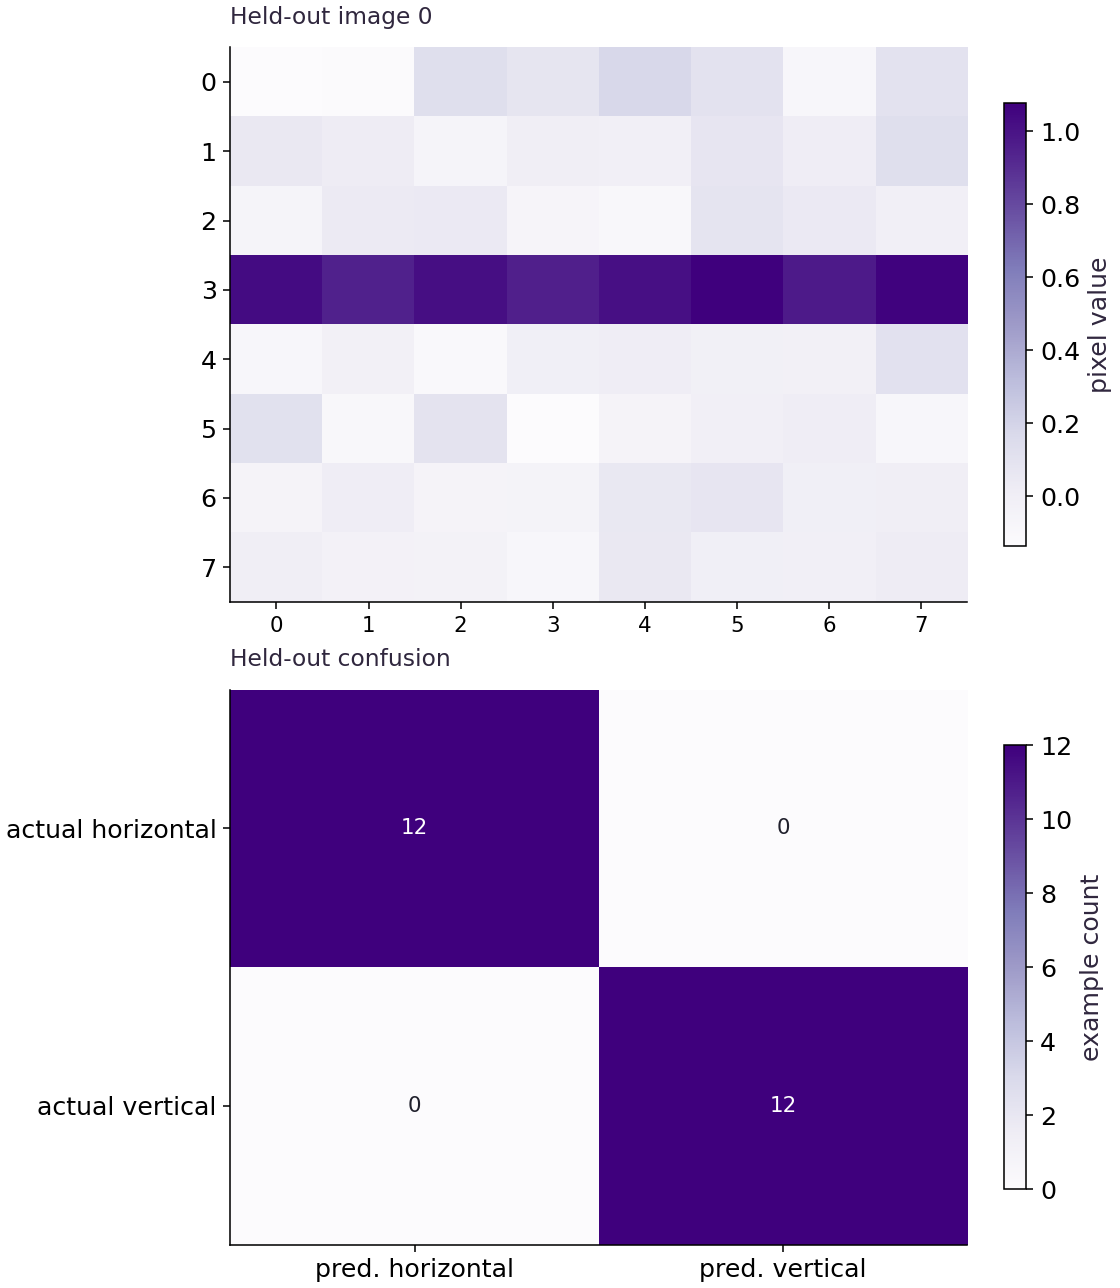

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The upper panel is one held-out image, with pixel columns across and rows down. Its dark horizontal stripe is near row $3$; the faint variation elsewhere is added noise. This color bar measures pixel value, so the picture is an input to the classifier.

The lower panel summarizes all held-out predictions. Rows are actual classes and columns are predicted classes. The two diagonal cells contain $12$ each; both off-diagonal cells contain zero. The lower color bar measures example count, which is a different quantity from pixel intensity.

### Connect it to the computation

The upper-left confusion cell counts horizontal images classified as horizontal; the lower-right counts vertical images classified as vertical. Off-diagonal counts would identify the two kinds of confusion. Here the $24$ held-out images are all classified correctly.

Use the sample image to understand the task and the confusion matrix to understand the observed errors. The single image cannot establish accuracy, and a zero in the matrix means no observed mistakes of that kind in this set, not that such a mistake is impossible. This is a small synthetic stripe task, not evidence of general image recognition.

## Trace a second patch and a second filter

Predict: If the spatial location changes to $(2,3)$, which input patch produces that output?

In [7]:
patch=np.asarray(test_x[0,2:5,3:6,:])
weights=np.asarray(model.conv.kernel[...])[:,:,:,2]
expected=np.sum(patch*weights)+np.asarray(model.conv.bias[...])[2]
np.testing.assert_allclose(model.conv(test_x[:1])[0,2,3,2],expected,rtol=1e-5,atol=1e-6)

Expected: The output uses rows $2$–$4$ and columns $3$–$5$ of the input.

The same learned filter is reused at each valid location; changing the output coordinate changes the patch, not the filter.

## Predict the chance classifier

Predict: On a balanced held-out split, what is the accuracy of always predicting class zero?

In [8]:
always_zero=np.zeros_like(labels)
baseline=np.mean(always_zero==labels)
assert baseline==.5
baseline_confusion=np.zeros((2,2),dtype=int)
np.add.at(baseline_confusion,(labels,always_zero),1)
np.testing.assert_array_equal(baseline_confusion,np.array([[12,0],[12,0]]))

Expected: Accuracy is $0.5$ with confusion $[[12,0]$,$[12,0]]$.

A majority or constant-label baseline is part of evaluation. A good-looking class-specific count alone can hide a useless predictor.

## Your exercise

Apply the trained model to one $10\times10$ image. Predict intermediate shape and parameter count before executing. Do not claim accuracy from an unlabeled input.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
larger=jnp.zeros((1,10,10,1));larger=larger.at[0,4,:,0].set(1.)
assert model.conv(larger).shape==(1,8,8,4)
assert model(larger).shape==(1,2)
assert sum(a.size for a in jax.tree.leaves(nnx.state(model,nnx.Param)))==50

## Read a confusion matrix as conditional rates · Transfer

Normalize each confusion-matrix row by its true-class count. Explain the diagonal and verify that weighting class recalls by class counts reproduces overall accuracy. Then remove a class in a constructed case and report its recall as undefined.

Hint: Keep the integer counts; a normalized row without a count hides how much evidence supports it.

In [11]:
# Write your attempt here.

## Reference reasoning

Each row asks where examples of one true class went. A missing class has no observed recall; assigning zero confuses missing evidence with demonstrated failure.

In [12]:
counts=confusion.sum(axis=1)
rates=np.divide(confusion,counts[:,None],out=np.full(confusion.shape,np.nan),where=counts[:,None]!=0)
np.testing.assert_allclose(rates.sum(axis=1),np.ones(2))
np.testing.assert_allclose((np.diag(rates)*counts).sum()/counts.sum(),accuracy)
missing=np.array([[3,1],[0,0]])
n=missing.sum(axis=1)
missing_rates=np.divide(missing,n[:,None],out=np.full(missing.shape,np.nan),where=n[:,None]!=0)
assert np.isnan(missing_rates[1]).all()
print('True-class counts:',counts,'row-normalized confusion:',rates)
print('Absent class recall: undefined, not zero.')

True-class counts: [12 12] row-normalized confusion: [[1. 0.]
 [0. 1.]]
Absent class recall: undefined, not zero.


## Catch a channel-order mistake · Intermediate

Transpose NHWC images to NCHW and show why this convolution rejects them. Repair the layout and compare predictions.

Hint: The final axis is the input-channel dimension for NNX Conv.

In [13]:
# Write your attempt here.

## Reference reasoning

The mistaken array has eight channels where the layer expects one. Explicit layout conversion is the repair; changing the declared channel count would silently change the model task.

In [14]:
wrong=jnp.transpose(test_x[:2],(0,3,1,2))
caught=False
try:model(wrong)
except (ValueError,TypeError):caught=True
assert caught
repaired=jnp.transpose(wrong,(0,2,3,1))
np.testing.assert_allclose(model(repaired),model(test_x[:2]),rtol=1e-6)

## Checkpoint

What does spatial mean pooling discard in this classifier?

1. The exact location of local responses
2. The number of output channels
3. All orientation-sensitive features

## Diagnose

Before tuning, inspect sample labels and input layout. Validate a convolution patch numerically, inspect prediction counts, and compare the constant baseline. If all predictions choose one class, examine class balance, score ranges, and per-class errors. If held-out samples equal training samples, repair the split before reporting metrics.

## Evidence

Keep the 8-by-8-to-6-by-6 shape diagram, NumPy patch dot product, seeds 20/21, independent held-out cross-entropy, 24-observation confusion matrix, constant-class baseline, and layout failure repair.

## Carry forward

- Generate images with an explicit label rule
- Derive the convolution output shape
- Pool spatial responses and retain class scores
- Read a confusion matrix rather than a success label

## Primary references

- [Flax NNX Conv API](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/nn/linear.html)
- [Optax classification losses](https://optax.readthedocs.io/en/latest/api/losses.html)